# Validation: Blob Helper On Count Mismatch

Compare the current segmented pipeline against two notebook-only count-mismatch repair policies:

- current segmented pipeline as-is
- segmented first-pass lines plus current vertical retry replacement
- segmented first-pass lines plus whole-blob helper replacement


In [1]:
from __future__ import annotations

import os
import sys
import time
from difflib import SequenceMatcher
from pathlib import Path

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    import pandas as pd
except Exception:
    pd = None


def find_repo(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return path
    raise RuntimeError("Run this notebook from the Master repo.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print("REPO:", REPO)

from app.io.dicom_loader import load_dicom_series
from app.pipeline.ai_pipeline import PipelineConfig
from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline
from app.pipeline.measurements.measurement_decoder import (
    canonicalize_exact_line,
    parse_measurement_line,
)
from app.pipeline.measurements.whole_blob_line_recovery import recover_lines_from_blob_text
from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine
from app.tools.batch.sweep_preprocessing_headless import _broad_configs, _build_preprocess_views
from app.validation.datasets import canonicalize_label_line, parse_labels
from app.validation.evaluation import score_predictions


LABELS_JSON = REPO / "labels" / "labels.json"
CONFIG_NAME = "gray_x3_lanczos"
ENGINE_NAME = "glm-ocr"
SPLIT = "validation"
STRATEGIES = (
    "current_segmented_pipeline",
    "count_mismatch_vertical_policy",
    "count_mismatch_blob_policy",
)
ONLY_NAMES: set[str] | None = None
MAX_FILES: int | None = None
FAILURE_PREVIEW_LIMIT = 25
DIAG_NAME: str | None = None
EXTERNAL_DICOM_ROOT = Path("/run/media/warre/T7/MIMIC-IV-ECHO/files")

if not LABELS_JSON.is_file():
    raise FileNotFoundError(f"Missing labels file: {LABELS_JSON}")
if EXTERNAL_DICOM_ROOT.is_dir():
    os.environ["ECHO_OCR_DICOM_ROOT"] = str(EXTERNAL_DICOM_ROOT)
    print(f"Using ECHO_OCR_DICOM_ROOT={EXTERNAL_DICOM_ROOT}")

sweep_cfg = next(cfg for cfg in _broad_configs() if cfg.name == CONFIG_NAME)
preprocess_views = _build_preprocess_views(sweep_cfg)
preprocess_full_roi = preprocess_views["default"]

try:
    whole_blob_engine = build_engine(ENGINE_NAME)
    segmented_pipe = EchoOcrPipeline(
        ocr_engine=whole_blob_engine,
        config=PipelineConfig(
            parameters={
                "ocr_engine": ENGINE_NAME,
                "requested_ocr_engine": ENGINE_NAME,
                "parser_mode": "off",
            }
        ),
    )
    segmented_pipe.ensure_components()
    segmented_pipe._line_transcriber.preprocess_views = preprocess_views
except UnavailableOcrEngineError as exc:
    raise RuntimeError(f"Could not start OCR engine {ENGINE_NAME!r}: {exc}") from exc

detector = segmented_pipe.box_detector

labeled_files = parse_labels(LABELS_JSON, split_filter={SPLIT})
if ONLY_NAMES is not None:
    labeled_files = [item for item in labeled_files if item.file_name in ONLY_NAMES]
if MAX_FILES is not None:
    labeled_files = labeled_files[: int(MAX_FILES)]

labeled_by_name = {item.file_name: item for item in labeled_files}

print(f"Loaded {len(labeled_files)} labeled files from split={SPLIT!r}")
print(f"Preprocess config: {CONFIG_NAME}")
print(f"OCR engine: {ENGINE_NAME}")


def measurement_to_prediction(measurement) -> dict[str, str | None]:
    return {
        "name": getattr(measurement, "name", None),
        "value": getattr(measurement, "value", None),
        "unit": getattr(measurement, "unit", None),
    }


def prediction_to_line(prediction: dict[str, str | None]) -> str:
    parts = [
        str(prediction.get("name") or "").strip(),
        str(prediction.get("value") or "").strip(),
        str(prediction.get("unit") or "").strip(),
    ]
    return canonicalize_label_line(" ".join(part for part in parts if part))


def display_table(rows: list[dict], *, limit: int | None = None) -> None:
    shown = rows if limit is None else rows[:limit]
    if pd is not None:
        display(pd.DataFrame(shown))
        return
    for row in shown:
        print(row)


def finalize_strategy_result(
    labeled_file,
    *,
    predictions: list[dict[str, str | None]],
    raw_ocr_texts: list[str],
    strategy_lines: list[str],
    helper_raw_ocr_texts: list[str],
    helper_recovered_lines: list[str],
    helper_sources: list[str],
    detected_frame_count: int,
    elapsed_s: float,
) -> dict[str, object]:
    match_results = score_predictions(labeled_file.measurements, predictions)
    return {
        "file_name": labeled_file.file_name,
        "file_path": str(labeled_file.path),
        "split": labeled_file.split,
        "labels": [item.text for item in labeled_file.measurements],
        "predicted_lines": [prediction_to_line(item) for item in predictions],
        "strategy_lines": list(strategy_lines),
        "raw_ocr_text": "\n\n".join(raw_ocr_texts),
        "helper_raw_ocr_text": "\n\n".join(helper_raw_ocr_texts),
        "helper_recovered_lines": list(helper_recovered_lines),
        "helper_sources": ", ".join(sorted({src for src in helper_sources if src})),
        "total_labels": len(labeled_file.measurements),
        "full_matches": sum(1 for item in match_results if item.full_match),
        "line_matches": sum(1 for item in match_results if item.line_match),
        "value_matches": sum(1 for item in match_results if item.value_match),
        "label_matches": sum(1 for item in match_results if item.label_match),
        "prefix_matches": sum(1 for item in match_results if item.prefix_match),
        "predicted_count": len(predictions),
        "detected_frame_count": detected_frame_count,
        "elapsed_s": elapsed_s,
    }


def lines_to_predictions(lines: list[str]) -> list[dict[str, str | None]]:
    predictions: list[dict[str, str | None]] = []
    for line in lines:
        decoded = parse_measurement_line(line)
        if not decoded.label or not decoded.value:
            continue
        name = f"{decoded.prefix} {decoded.label}".strip() if decoded.prefix else decoded.label
        predictions.append(
            {
                "name": name,
                "value": decoded.value,
                "unit": decoded.unit,
            }
        )
    return predictions


def _decoded_bits(text: str) -> dict[str, str]:
    canonical = canonicalize_exact_line(text)
    decoded = parse_measurement_line(canonical) if canonical else None
    return {
        "text": canonical,
        "label": str(getattr(decoded, "label", "") or "").strip().lower(),
        "value": str(getattr(decoded, "value", "") or "").strip(),
        "unit": str(getattr(decoded, "unit", "") or "").strip().lower(),
        "prefix": str(getattr(decoded, "prefix", "") or "").strip(),
    }


def _alignment_similarity(base_text: str, recovered_text: str) -> float:
    base = _decoded_bits(base_text)
    recovered = _decoded_bits(recovered_text)
    if not recovered["text"]:
        return -4.0

    score = SequenceMatcher(None, base["text"].lower(), recovered["text"].lower()).ratio() * 4.0
    if base["label"] and recovered["label"]:
        if base["label"] == recovered["label"]:
            score += 5.0
        elif base["label"] in recovered["label"] or recovered["label"] in base["label"]:
            score += 2.0
    if base["unit"] and recovered["unit"] and base["unit"] == recovered["unit"]:
        score += 1.0
    if base["prefix"] and recovered["prefix"] and base["prefix"] == recovered["prefix"]:
        score += 1.0
    if recovered["value"]:
        score += 0.5
    return score


def _align_recovered_lines(panel_lines, recovered_lines: list[str]) -> tuple[dict[int, str], dict[int, float]]:
    ordered_panel_lines = sorted(panel_lines, key=lambda item: int(item.order))
    panel_orders = [int(line.order) for line in ordered_panel_lines]
    panel_texts: list[str] = []
    for line in ordered_panel_lines:
        metadata = dict(line.metadata or {})
        current_text = canonicalize_exact_line(str(line.text or ""))
        first_pass_text = canonicalize_exact_line(str(metadata.get("pre_char_line_text") or ""))
        panel_texts.append(first_pass_text or current_text)

    cleaned_recovered = [canonicalize_exact_line(text) for text in recovered_lines if canonicalize_exact_line(text)]
    n = len(panel_texts)
    m = len(cleaned_recovered)
    neg_inf = -10**9
    dp = [[neg_inf] * (m + 1) for _ in range(n + 1)]
    move: list[list[tuple[str, float] | None]] = [[None] * (m + 1) for _ in range(n + 1)]
    dp[0][0] = 0.0

    def panel_skip_penalty(text: str) -> float:
        return 0.2 if not text.strip() else 1.25

    for i in range(n + 1):
        for j in range(m + 1):
            current_score = dp[i][j]
            if current_score <= neg_inf / 2:
                continue
            if i < n:
                skip_score = current_score - panel_skip_penalty(panel_texts[i])
                if skip_score > dp[i + 1][j]:
                    dp[i + 1][j] = skip_score
                    move[i + 1][j] = ("skip_panel", 0.0)
            if j < m:
                skip_score = current_score - 1.0
                if skip_score > dp[i][j + 1]:
                    dp[i][j + 1] = skip_score
                    move[i][j + 1] = ("skip_recovered", 0.0)
            if i < n and j < m:
                sim = _alignment_similarity(panel_texts[i], cleaned_recovered[j])
                match_score = current_score + sim
                if match_score > dp[i + 1][j + 1]:
                    dp[i + 1][j + 1] = match_score
                    move[i + 1][j + 1] = ("match", sim)

    aligned_text_by_order: dict[int, str] = {}
    aligned_score_by_order: dict[int, float] = {}
    i = n
    j = m
    while i > 0 or j > 0:
        step = move[i][j]
        if step is None:
            break
        kind, sim = step
        if kind == "match":
            order = panel_orders[i - 1]
            aligned_text_by_order[order] = cleaned_recovered[j - 1]
            aligned_score_by_order[order] = float(sim)
            i -= 1
            j -= 1
        elif kind == "skip_panel":
            i -= 1
        else:
            j -= 1

    return aligned_text_by_order, aligned_score_by_order


def reconstruct_count_mismatch_policies(panel_lines, recovered_lines: list[str], *, frame_index: int, recovery_source: str) -> tuple[list[str], list[str], list[dict[str, object]]]:
    ordered_panel_lines = sorted(panel_lines, key=lambda item: int(item.order))
    recovered_by_order, alignment_score_by_order = _align_recovered_lines(panel_lines, recovered_lines)

    vertical_lines: list[str] = []
    blob_lines: list[str] = []
    diagnostics: list[dict[str, object]] = []

    for line in ordered_panel_lines:
        order = int(line.order)
        metadata = dict(line.metadata or {})
        current_text = canonicalize_exact_line(str(line.text or ""))
        first_pass_text = canonicalize_exact_line(str(metadata.get("pre_char_line_text") or ""))
        base_alignment_text = first_pass_text or current_text

        expected_char_count = int(metadata.get("char_count_expected") or 0)
        first_pass_count_matches = bool(metadata.get("line_ocr_count_matches"))
        vertical_retry_text = canonicalize_exact_line(str(metadata.get("vertical_slice_retry_text") or ""))
        vertical_retry_count_matches = bool(metadata.get("vertical_slice_retry_count_matches"))
        recovered_text = recovered_by_order.get(order, "")
        alignment_score = float(alignment_score_by_order.get(order, 0.0))
        base_bits = _decoded_bits(base_alignment_text)
        recovered_bits = _decoded_bits(recovered_text)
        blob_parse_ok = bool(recovered_bits["label"] and recovered_bits["value"])
        blob_label_match = bool(base_bits["label"] and recovered_bits["label"] and base_bits["label"] == recovered_bits["label"])

        use_vertical = bool(
            not first_pass_count_matches
            and expected_char_count > 0
            and vertical_retry_count_matches
            and vertical_retry_text.strip()
        )
        use_blob = bool(
            not first_pass_count_matches
            and expected_char_count > 0
            and recovered_text.strip()
            and blob_parse_ok
            and (blob_label_match or not base_alignment_text.strip() or alignment_score >= 4.0)
        )

        vertical_text = vertical_retry_text if use_vertical else current_text
        blob_text = recovered_text if use_blob else current_text
        if not vertical_text.strip():
            vertical_text = base_alignment_text
        if not blob_text.strip():
            blob_text = base_alignment_text

        vertical_lines.append(vertical_text)
        blob_lines.append(blob_text)
        diagnostics.append(
            {
                "frame_index": frame_index,
                "line_order": order,
                "expected_char_count": expected_char_count,
                "first_pass_count_matches": first_pass_count_matches,
                "current_pipeline_text": current_text,
                "current_best_source": str(metadata.get("best_text_source") or ""),
                "first_pass_text": first_pass_text,
                "vertical_retry_text": vertical_retry_text,
                "vertical_retry_count_matches": vertical_retry_count_matches,
                "vertical_selected_text": vertical_text,
                "vertical_selected_source": "vertical_retry" if use_vertical else "current_pipeline",
                "blob_recovered_text": recovered_text,
                "blob_recovery_source": recovery_source,
                "blob_alignment_score": round(alignment_score, 3),
                "blob_parse_ok": blob_parse_ok,
                "blob_label_match": blob_label_match,
                "blob_selected_text": blob_text,
                "blob_selected_source": "blob_helper" if use_blob else "current_pipeline",
                "review_status": str(metadata.get("review_status") or ""),
            }
        )

    return vertical_lines, blob_lines, diagnostics


def evaluate_file_all_strategies(labeled_file) -> tuple[dict[str, dict[str, object]], list[dict[str, object]]]:
    started = time.perf_counter()
    series = load_dicom_series(labeled_file.path, load_pixels=True)

    current_predictions: list[dict[str, str | None]] = []
    current_raw_texts: list[str] = []
    current_lines: list[str] = []
    current_detected_frames = 0

    vertical_predictions: list[dict[str, str | None]] = []
    vertical_raw_texts: list[str] = []
    vertical_lines_all: list[str] = []
    vertical_detected_frames = 0

    blob_predictions: list[dict[str, str | None]] = []
    blob_raw_texts: list[str] = []
    blob_lines_all: list[str] = []
    blob_detected_frames = 0

    helper_raw_texts: list[str] = []
    helper_recovered_lines: list[str] = []
    helper_sources: list[str] = []
    line_diagnostics: list[dict[str, object]] = []

    for frame_index in range(series.frame_count):
        frame = series.get_frame(frame_index)
        _det, _segmentation, segmented_ocr, panel, segmented_measurements, bbox = segmented_pipe.analyze_frame_with_debug(frame)
        if bbox is None:
            continue

        current_predictions.extend(measurement_to_prediction(item) for item in segmented_measurements)
        if segmented_ocr is not None and segmented_ocr.text.strip():
            current_raw_texts.append(f"[frame {frame_index}]\n{segmented_ocr.text}")
        current_lines.extend(canonicalize_exact_line(line.text) for line in panel.lines if canonicalize_exact_line(line.text))
        current_detected_frames += 1

        x, y, bw, bh = bbox
        roi = frame[y : y + bh, x : x + bw]
        prepared = preprocess_full_roi(roi)
        helper_ocr = whole_blob_engine.extract(prepared)
        helper_raw_texts.append(f"[frame {frame_index}]\n{helper_ocr.text}")

        recovered_lines, recovery_debug = recover_lines_from_blob_text(
            helper_ocr.text,
            target_line_count=len(panel.lines),
        )
        recovery_source = str(recovery_debug.get("source") or "")
        helper_recovered_lines.extend(recovered_lines)
        if recovery_source:
            helper_sources.append(recovery_source)

        frame_vertical_lines, frame_blob_lines, frame_diagnostics = reconstruct_count_mismatch_policies(
            panel.lines,
            recovered_lines,
            frame_index=frame_index,
            recovery_source=recovery_source,
        )
        vertical_predictions.extend(lines_to_predictions([line for line in frame_vertical_lines if line.strip()]))
        blob_predictions.extend(lines_to_predictions([line for line in frame_blob_lines if line.strip()]))
        vertical_raw_texts.append(f"[frame {frame_index}]\n" + "\n".join(frame_vertical_lines))
        blob_raw_texts.append(f"[frame {frame_index}]\n" + "\n".join(frame_blob_lines))
        vertical_lines_all.extend(line for line in frame_vertical_lines if line.strip())
        blob_lines_all.extend(line for line in frame_blob_lines if line.strip())
        vertical_detected_frames += 1
        blob_detected_frames += 1
        line_diagnostics.extend(frame_diagnostics)

    elapsed_s = time.perf_counter() - started
    return {
        "current_segmented_pipeline": finalize_strategy_result(
            labeled_file,
            predictions=current_predictions,
            raw_ocr_texts=current_raw_texts,
            strategy_lines=current_lines,
            helper_raw_ocr_texts=helper_raw_texts,
            helper_recovered_lines=helper_recovered_lines,
            helper_sources=helper_sources,
            detected_frame_count=current_detected_frames,
            elapsed_s=elapsed_s,
        ),
        "count_mismatch_vertical_policy": finalize_strategy_result(
            labeled_file,
            predictions=vertical_predictions,
            raw_ocr_texts=vertical_raw_texts,
            strategy_lines=vertical_lines_all,
            helper_raw_ocr_texts=helper_raw_texts,
            helper_recovered_lines=helper_recovered_lines,
            helper_sources=helper_sources,
            detected_frame_count=vertical_detected_frames,
            elapsed_s=elapsed_s,
        ),
        "count_mismatch_blob_policy": finalize_strategy_result(
            labeled_file,
            predictions=blob_predictions,
            raw_ocr_texts=blob_raw_texts,
            strategy_lines=blob_lines_all,
            helper_raw_ocr_texts=helper_raw_texts,
            helper_recovered_lines=helper_recovered_lines,
            helper_sources=helper_sources,
            detected_frame_count=blob_detected_frames,
            elapsed_s=elapsed_s,
        ),
    }, line_diagnostics


REPO: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master
Using ECHO_OCR_DICOM_ROOT=/run/media/warre/T7/MIMIC-IV-ECHO/files


The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded 353 labeled files from split='validation'
Preprocess config: gray_x3_lanczos
OCR engine: glm-ocr


In [2]:
results_by_strategy = {name: [] for name in STRATEGIES}
missing_file_errors: list[dict[str, str]] = []
runtime_errors: list[dict[str, str]] = []
line_diagnostics_by_file: dict[str, list[dict[str, object]]] = {}

for index, labeled_file in enumerate(labeled_files, start=1):
    if index == 1 or index % 25 == 0 or index == len(labeled_files):
        print(f"[{index}/{len(labeled_files)}] {labeled_file.file_name}")
    try:
        file_results, file_line_diagnostics = evaluate_file_all_strategies(labeled_file)
        for strategy_name in STRATEGIES:
            results_by_strategy[strategy_name].append(file_results[strategy_name])
        line_diagnostics_by_file[labeled_file.file_name] = file_line_diagnostics
    except Exception as exc:
        err = {
            "file_name": labeled_file.file_name,
            "file_path": str(labeled_file.path),
            "error": repr(exc),
        }
        if "File not found" in err["error"]:
            missing_file_errors.append(err)
        else:
            runtime_errors.append(err)

summary_rows: list[dict[str, object]] = []
for strategy_name in STRATEGIES:
    rows = results_by_strategy[strategy_name]
    total_labels = sum(int(item["total_labels"]) for item in rows)
    exact_matches = sum(int(item["full_matches"]) for item in rows)
    line_matches = sum(int(item["line_matches"]) for item in rows)
    value_matches = sum(int(item["value_matches"]) for item in rows)
    summary_rows.append(
        {
            "strategy": strategy_name,
            "files_processed": len(rows),
            "files_missing": len(missing_file_errors),
            "runtime_errors": len(runtime_errors),
            "files_with_detected_roi": sum(1 for item in rows if int(item["detected_frame_count"]) > 0),
            "total_labels": total_labels,
            "exact_matches": exact_matches,
            "exact_errors": total_labels - exact_matches,
            "exact_match_rate": round(exact_matches / max(total_labels, 1), 4),
            "line_match_rate": round(line_matches / max(total_labels, 1), 4),
            "value_match_rate": round(value_matches / max(total_labels, 1), 4),
            "predicted_measurements": sum(int(item["predicted_count"]) for item in rows),
            "mean_seconds_per_file": round(
                sum(float(item["elapsed_s"]) for item in rows) / max(len(rows), 1),
                3,
            ),
        }
    )

current_by_name = {item["file_name"]: item for item in results_by_strategy["current_segmented_pipeline"]}
vertical_by_name = {item["file_name"]: item for item in results_by_strategy["count_mismatch_vertical_policy"]}
blob_by_name = {item["file_name"]: item for item in results_by_strategy["count_mismatch_blob_policy"]}

comparison_rows: list[dict[str, object]] = []
for file_name, current_result in current_by_name.items():
    vertical_result = vertical_by_name[file_name]
    blob_result = blob_by_name[file_name]
    comparison_rows.append(
        {
            "file_name": file_name,
            "labels": current_result["total_labels"],
            "current_exact": current_result["full_matches"],
            "vertical_exact": vertical_result["full_matches"],
            "blob_exact": blob_result["full_matches"],
            "blob_minus_current": int(blob_result["full_matches"]) - int(current_result["full_matches"]),
            "blob_minus_vertical": int(blob_result["full_matches"]) - int(vertical_result["full_matches"]),
            "vertical_minus_current": int(vertical_result["full_matches"]) - int(current_result["full_matches"]),
            "helper_source": blob_result["helper_sources"],
        }
    )

comparison_rows.sort(
    key=lambda row: (
        -int(row["blob_minus_current"]),
        -int(row["blob_minus_vertical"]),
        -int(row["blob_exact"]),
        str(row["file_name"]),
    )
)

blob_gains_vs_current = [row for row in comparison_rows if int(row["blob_minus_current"]) > 0]
blob_regressions_vs_current = [row for row in comparison_rows if int(row["blob_minus_current"]) < 0]
blob_gains_vs_vertical = [row for row in comparison_rows if int(row["blob_minus_vertical"]) > 0]

all_line_diagnostics = [
    {"file_name": file_name, **row}
    for file_name, rows in line_diagnostics_by_file.items()
    for row in rows
]
blob_helper_rows = [row for row in all_line_diagnostics if row["blob_selected_source"] == "blob_helper"]
vertical_retry_rows = [row for row in all_line_diagnostics if row["vertical_selected_source"] == "vertical_retry"]

blob_failures = [
    {
        "file_name": item["file_name"],
        "total_labels": item["total_labels"],
        "exact_matches": item["full_matches"],
        "exact_errors": int(item["total_labels"]) - int(item["full_matches"]),
        "predicted_lines": " | ".join(item["predicted_lines"]),
        "strategy_lines": " | ".join(item["strategy_lines"]),
        "helper_recovered_lines": " | ".join(item["helper_recovered_lines"]),
        "helper_raw_ocr_text": item["helper_raw_ocr_text"],
        "helper_sources": item["helper_sources"],
    }
    for item in results_by_strategy["count_mismatch_blob_policy"]
    if int(item["full_matches"]) < int(item["total_labels"])
]
blob_failures.sort(key=lambda row: (-int(row["exact_errors"]), str(row["file_name"])))


[1/353] 91243943_0004.dcm
[25/353] 91629559_0027.dcm
[50/353] 92290733_0071.dcm
[75/353] 93330659_0103.dcm
[100/353] 93489296_0068.dcm
[125/353] 94106955_0046.dcm
[150/353] 94134445_0042.dcm
[175/353] 95253372_0042.dcm
[200/353] 97273331_0029.dcm
[225/353] 97555635_0102.dcm
[250/353] 98667422_0037.dcm
[275/353] 99094104_0042.dcm
[300/353] 99583722_0015.dcm
[325/353] 99583722_0092.dcm
[350/353] 99663585_0107.dcm
[353/353] 99663585_0110.dcm


In [3]:
print("Strategy summary")
display_table(summary_rows)

print(f"Blob helper applied on {len(blob_helper_rows)} lines")
print(f"Vertical retry applied on {len(vertical_retry_rows)} lines")
print(f"Missing files: {len(missing_file_errors)}")
print(f"Runtime errors: {len(runtime_errors)}")

print("Blob helper gains over current segmented pipeline")
if blob_gains_vs_current:
    display_table(blob_gains_vs_current, limit=FAILURE_PREVIEW_LIMIT)
else:
    print("No file-level gains over current segmented pipeline in this run.")

print("Blob helper gains over notebook vertical policy")
if blob_gains_vs_vertical:
    display_table(blob_gains_vs_vertical, limit=FAILURE_PREVIEW_LIMIT)
else:
    print("No file-level gains over the notebook vertical policy in this run.")

print("Worst blob helper regressions vs current segmented pipeline")
display_table(blob_regressions_vs_current, limit=FAILURE_PREVIEW_LIMIT)

print("Example blob helper substitutions")
display_table(blob_helper_rows, limit=FAILURE_PREVIEW_LIMIT)

print("Blob policy failure preview")
display_table(blob_failures, limit=FAILURE_PREVIEW_LIMIT)

if missing_file_errors:
    print("Missing file paths")
    display_table(missing_file_errors, limit=FAILURE_PREVIEW_LIMIT)
if runtime_errors:
    print("Runtime errors")
    display_table(runtime_errors, limit=FAILURE_PREVIEW_LIMIT)


Strategy summary
{'strategy': 'current_segmented_pipeline', 'files_processed': 353, 'files_missing': 0, 'runtime_errors': 0, 'files_with_detected_roi': 353, 'total_labels': 901, 'exact_matches': 875, 'exact_errors': 26, 'exact_match_rate': 0.9711, 'line_match_rate': 0.9711, 'value_match_rate': 0.9711, 'predicted_measurements': 898, 'mean_seconds_per_file': 2.273}
{'strategy': 'count_mismatch_vertical_policy', 'files_processed': 353, 'files_missing': 0, 'runtime_errors': 0, 'files_with_detected_roi': 353, 'total_labels': 901, 'exact_matches': 439, 'exact_errors': 462, 'exact_match_rate': 0.4872, 'line_match_rate': 0.4872, 'value_match_rate': 0.4939, 'predicted_measurements': 494, 'mean_seconds_per_file': 2.273}
{'strategy': 'count_mismatch_blob_policy', 'files_processed': 353, 'files_missing': 0, 'runtime_errors': 0, 'files_with_detected_roi': 353, 'total_labels': 901, 'exact_matches': 873, 'exact_errors': 28, 'exact_match_rate': 0.9689, 'line_match_rate': 0.9689, 'value_match_rate': 0.

99663585_0069.dcm
Expected labels:
  - AVA Vmax 2.7 cm2
  - AVA (VTI) 2.7 cm2
  - 1 AV Vmax 1.8 m/s
  - 1 AV Vmean 1.2 m/s
  - AV maxPG 13 mmHg
  - AV meanPG 7 mmHg
  - AV VTI 36.5 cm

Current segmented pipeline:
  - AVA Vmax 2.7 cm2
  - AVA (VTI) 2.7 cm2
  - 1 AV Vmax 1.8 m/s
  - 1 AV Vmean 1.2 m/s
  - AV maxPG 13 mmHg
  - AV meanPG 7 mmHg
  - AV VTI 36.5 cm

Notebook vertical policy:
  - AVA (VTI) 2.7 cm2
  - AV VTI 36.5 cm

Notebook blob policy:
  - AVA Vmax 2.7 cm2
  - AVA (VTI) 2.7 cm2
  - 1 AV Vmax 1.8 m/s
  - AV Vmean 1.2 m/s
  - AV maxPG 13 mmHg
  - AV meanPG 7 mmHg
  - AV VTI 36.5 cm

Whole-blob helper raw OCR:
[frame 0]
AVA Vmax 2.7 cm2
AVA (VTI) 2.7 cm2
1 AV Vmax 1.8 m/s
AV Vmean 1.2 m/s
AV maxPG 13 mmHg
AV meanPG 7 mmHg
AV VTI 36.5 cm
helper_sources=raw_newlines_relaxed

Per-line diagnostics
{'frame_index': 0, 'line_order': 0, 'expected_char_count': 1, 'first_pass_count_matches': False, 'current_pipeline_text': '', 'current_best_source': 'pipeline_final', 'first_pass_text':

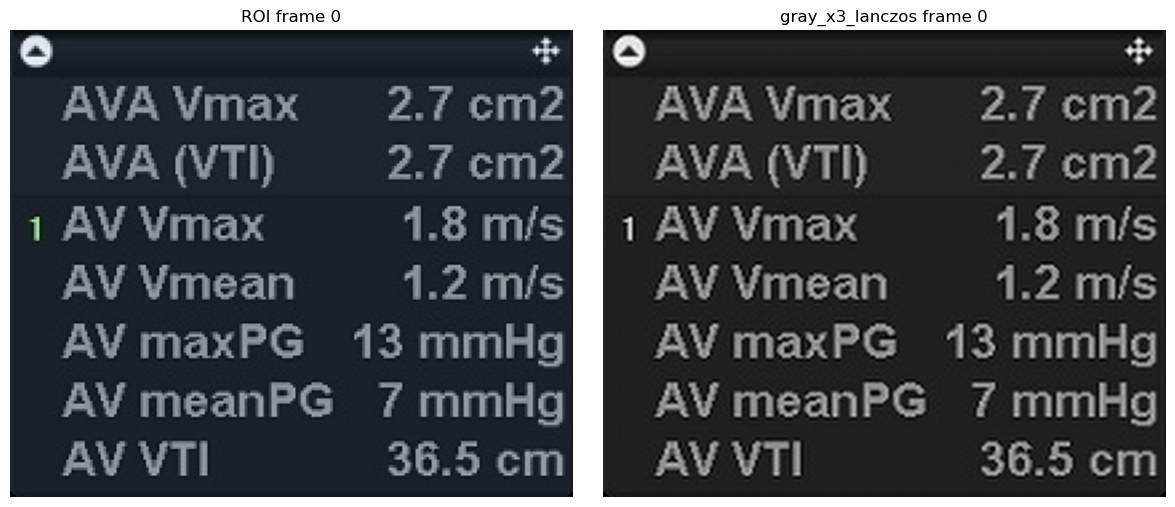

In [4]:
def _show_image(ax, image, title: str) -> None:
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")


def show_diagnostics(file_name: str) -> None:
    current_result = current_by_name[file_name]
    vertical_result = vertical_by_name[file_name]
    blob_result = blob_by_name[file_name]
    line_rows = line_diagnostics_by_file.get(file_name, [])

    print(file_name)
    print("Expected labels:")
    for line in current_result["labels"]:
        print("  -", line)

    print("\nCurrent segmented pipeline:")
    for line in current_result["predicted_lines"]:
        print("  -", line)

    print("\nNotebook vertical policy:")
    for line in vertical_result["predicted_lines"]:
        print("  -", line)

    print("\nNotebook blob policy:")
    for line in blob_result["predicted_lines"]:
        print("  -", line)

    print("\nWhole-blob helper raw OCR:")
    print(blob_result["helper_raw_ocr_text"] or "<empty>")
    print(f"helper_sources={blob_result['helper_sources']}")

    if line_rows:
        print("\nPer-line diagnostics")
        display_table(line_rows)

    if plt is None:
        print("matplotlib unavailable; skip ROI visualization.")
        return

    labeled_file = labeled_by_name[file_name]
    series = load_dicom_series(labeled_file.path, load_pixels=True)
    for frame_index in range(series.frame_count):
        frame = series.get_frame(frame_index)
        detection = detector.detect(frame)
        if not detection.present or detection.bbox is None:
            continue
        x, y, bw, bh = detection.bbox
        roi = frame[y : y + bh, x : x + bw]
        prepared = preprocess_full_roi(roi)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        _show_image(axes[0], roi, f"ROI frame {frame_index}")
        _show_image(axes[1], prepared, f"{CONFIG_NAME} frame {frame_index}")
        fig.tight_layout()
        plt.show()
        break


if DIAG_NAME is None and blob_regressions_vs_current:
    DIAG_NAME = str(blob_regressions_vs_current[0]["file_name"])
elif DIAG_NAME is None and blob_failures:
    DIAG_NAME = str(blob_failures[0]["file_name"])

if DIAG_NAME is not None:
    show_diagnostics(DIAG_NAME)
else:
    print("No files to inspect.")
